## Autler-Townes Splitting Analysis for n = 63

## Data taken on 9 April 2026

### Prepared by LTC Brian C. Holloway

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
import scipy.constants as const
from arc import *

### Determine peak spacing using Voigt profile fitting (most precise)

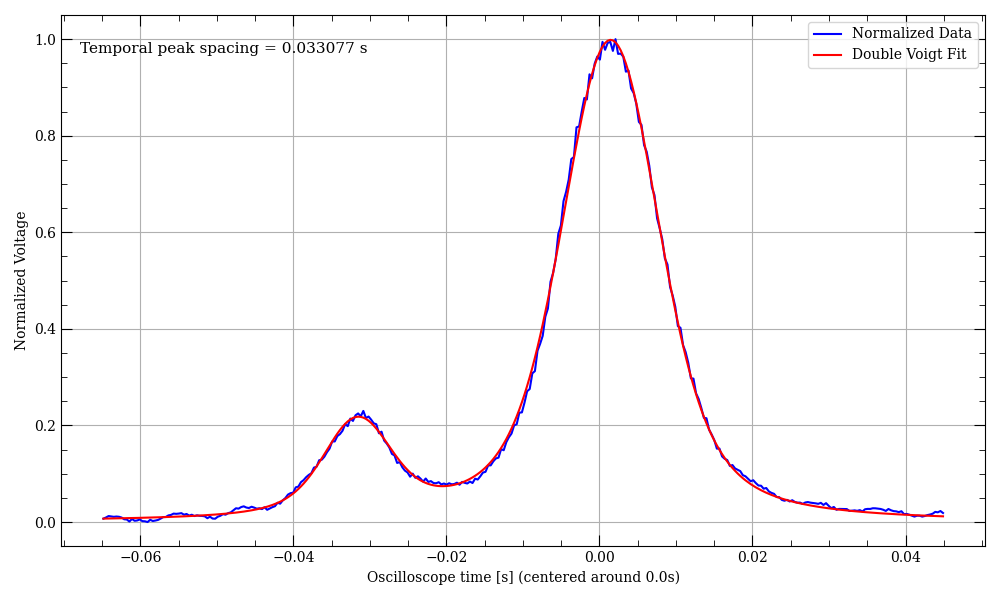

### The code cell below is the cornerstone upon which the rest of the analysis depends.  The time to frequency scaling factor is critical.

In [2]:
t_d = 33.07 # [ms] this is the temporal spacing between the D3/2 and D5/2 EIT peaks calculated from Voigt fitting (most precise)
sf = 1 # time axis scaling factor (set to unity since the probe is fixed)
freq_sep = 45.60 # [Mhz] this is the frequency spacing between the D3/2 and D5/2 EIT peaks from quantum defect calculation (see n65 Peak Spacing Analysis 30 March)
f = (freq_sep * sf)/t_d # this is the time to frequency scaling factor

### Autler-Townes splitting and Experimental TDME extraction

Extracted dipole matrix element (μ): 4583.82 ± 81.48 MHz per √mW
R² value of the fit: 0.9880


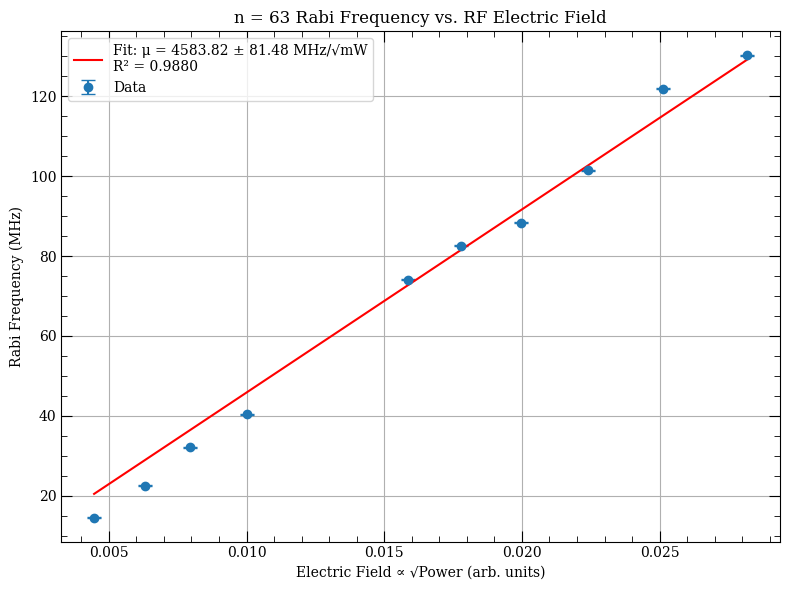

In [3]:
p_dbm = np.array([-17, -14, -12, -10, -6, -5, -4, -3, -2, -1]) # signal generator powers in dBm
rabi_freqs_mhz = f * np.array([10.5, 16.3, 23.3, 29.3, 53.7, 59.9, 64.1, 73.6, 88.4, 94.5]) # oscilloscope measured peak splitting in milliseconds
rabi_errors_mhz = f * np.ones(len(rabi_freqs_mhz))/10 # uncertainty peak separation measurements in milliseconds


################################################
# Convert RF power from dBm to linear scale (W)
rf_powers_W = (10 ** (p_dbm / 10))/1000
################################################

# Electric field amplitude is proportional to sqrt(power)
rf_field = np.sqrt(rf_powers_W)

# Fit Rabi frequency vs. electric field to a linear model: Omega = mu * E / hbar
def linear_model(x, mu):
    return mu * x

popt, pcov = curve_fit(linear_model, rf_field, rabi_freqs_mhz, sigma=rabi_errors_mhz)
mu_fit = popt[0]
mu_err = np.sqrt(np.diag(pcov))[0]

# Generate fit line
rf_field_fit = np.linspace(min(rf_field), max(rf_field), 100)
rabi_fit_line = linear_model(rf_field_fit, mu_fit)

# Calculate R² value
residuals = rabi_freqs_mhz - linear_model(rf_field, mu_fit)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((rabi_freqs_mhz - np.mean(rabi_freqs_mhz))**2)
r_squared = 1 - (ss_res / ss_tot)

# Plotting with matplotlib
plt.figure(figsize=(8, 6))
plt.errorbar(rf_field, rabi_freqs_mhz, yerr=rabi_errors_mhz, fmt='o', label='Data', capsize=5)
plt.plot(rf_field_fit, rabi_fit_line, label=f'Fit: μ = {mu_fit:.2f} ± {mu_err:.2f} MHz/√mW\nR² = {r_squared:.4f}', color='red')
plt.xlabel('Electric Field ∝ √Power (arb. units)')
plt.ylabel('Rabi Frequency (MHz)')
plt.title('n = 63 Rabi Frequency vs. RF Electric Field')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Report dipole matrix element and R²
print(f"Extracted dipole matrix element (μ): {mu_fit:.2f} ± {mu_err:.2f} MHz per √mW")
print(f"R² value of the fit: {r_squared:.4f}")

##  ARC generated TDME extraction

### ARC requires the E-field magnitude as an input parameter to calculate the TDME.

### The code cell below calculated the peak E-field values.

In [4]:
# This code cell below defines the geometry and implements equation A8 from https://iopscience.iop.org/article/10.1088/1361-6455/ae407f
g_dbi = 15 # [dBi] nominal gain of the antenna from manufacturer specs; this accounts for the fact the horn is directional.
r = 0.35 # [m] distance from horn to vapor cell; RF horn is perpendicular to the vapor cell longitudinal axis 
P = (10**(p_dbm/10))/1000 # power [W]
G = (10**(g_dbi/10)) # linear gain [unitless]
E_peak = (1/r) * np.sqrt(60 * P * G) #[V/m] peak field strength
print("Peak Electric field strengths [V/m]:", E_peak)

Peak Electric field strengths [V/m]: [0.55591396 0.78524934 0.98857035 1.24453634 1.97245717 2.21313334
 2.48317645 2.7861698  3.12613393 3.50757997]


### The code cell below calculates the Rabi frequencies that correspond to the peak E-field values.

In [5]:
# Define atom and quantum numbers
atom = Rubidium()
n1 = 63 # principal quantum number
l1 = 2 # D-state
j1 = 2.5 # J = L + S
mj1 = 0.5 # pick an m_j in the manifold
n3 = n1 + 1 # neaby Rydberg state
l3 = l1 - 1 # P-state
j3 = l3 + 0.5 # J = L + S
q = 0 # linearly polarized light
mj2 = mj1 # no change in m_j value

# Electric field values (V/m)
WW = E_peak # container for peak E-field values

rabi_frequencies = []

for i, E in enumerate(WW):
    try:
        rabi = atom.getRabiFrequency2(n1, l1, j1, mj1, n3, l3, j3, q, E) / (2 * np.pi * 1e6)
        rabi_frequencies.append(rabi)
    except Exception as e:
        print(f"Error at index {i} (E = {E:.2f} V/m): {e}")
        rabi_frequencies.append(np.nan)  # Use NaN to preserve array length
# Print results
print(f"\nResults for PQN = {n1}:")
print("Rb Rydberg Transition nD_{5/2} → n+1 P_{3/2}")
print("===========================================")
for E, rabi in zip(WW, rabi_frequencies):
    print(f"E = {E:.2f} V/m → Rabi Frequency = {rabi:.3f} MHz")

# Store results in a dictionary
results = {
    'electric_fields': WW,
    'rabi_frequencies': rabi_frequencies,
}


Results for PQN = 63:
Rb Rydberg Transition nD_{5/2} → n+1 P_{3/2}
E = 0.56 V/m → Rabi Frequency = 17.979 MHz
E = 0.79 V/m → Rabi Frequency = 25.396 MHz
E = 0.99 V/m → Rabi Frequency = 31.972 MHz
E = 1.24 V/m → Rabi Frequency = 40.250 MHz
E = 1.97 V/m → Rabi Frequency = 63.792 MHz
E = 2.21 V/m → Rabi Frequency = 71.576 MHz
E = 2.48 V/m → Rabi Frequency = 80.310 MHz
E = 2.79 V/m → Rabi Frequency = 90.109 MHz
E = 3.13 V/m → Rabi Frequency = 101.104 MHz
E = 3.51 V/m → Rabi Frequency = 113.441 MHz


### Now that we have the ARC-generated Rabi frequencies we can make a plot.

Extracted dipole matrix element (μ): 4025.03 ± 0.00 MHz per √mW
R² value of the fit: 1.0000


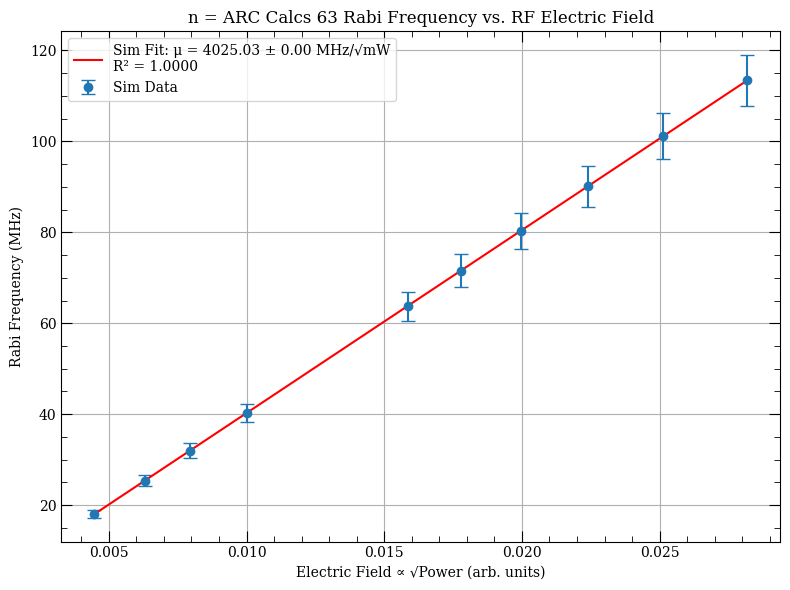

In [6]:
# I added a captial "S" to each parameter to indicate simulated data from ARC

eff_field_scale = 1.0 # NO SCALING

# Pull Rabi frequencies directly from the results dictionary
rabi_freqs_mhzS = np.array(results['rabi_frequencies'], dtype=float) * eff_field_scale

rabi_errors_mhzS = rabi_freqs_mhzS * 0.05 # 5 % nominal uncertainty

################################################
# Convert RF power from dBm to linear scale (W)
rf_powers_WS = (10 ** (p_dbm / 10))/1000
################################################

# Electric field amplitude is proportional to sqrt(power)
rf_fieldS = np.sqrt(rf_powers_WS)

# Fit Rabi frequency vs. electric field to a linear model: Omega = mu * E / hbar
def linear_model(x, mu):
    return mu * x

popt, pcov = curve_fit(linear_model, rf_fieldS, rabi_freqs_mhzS, sigma=rabi_errors_mhzS)
mu_fitS = popt[0]
mu_errS = np.sqrt(np.diag(pcov))[0]

# Generate fit line
rf_field_fitS = np.linspace(min(rf_fieldS), max(rf_fieldS), 100)
rabi_fit_lineS = linear_model(rf_field_fitS, mu_fitS)

# Calculate R² value
residualsS = rabi_freqs_mhzS - linear_model(rf_fieldS, mu_fitS)
ss_resS = np.sum(residualsS**2)
ss_totS = np.sum((rabi_freqs_mhzS - np.mean(rabi_freqs_mhzS))**2)
r_squaredS = 1 - (ss_resS / ss_totS)

# Plotting with matplotlib
plt.figure(figsize=(8, 6))
plt.errorbar(rf_fieldS, rabi_freqs_mhzS, yerr=rabi_errors_mhzS, fmt='o', label='Sim Data', capsize=5)
plt.plot(rf_field_fitS, rabi_fit_lineS, label=f'Sim Fit: μ = {mu_fitS:.2f} ± {mu_errS:.2f} MHz/√mW\nR² = {r_squaredS:.4f}', color='red')
plt.xlabel('Electric Field ∝ √Power (arb. units)')
plt.ylabel('Rabi Frequency (MHz)')
plt.title('n = ARC Calcs 63 Rabi Frequency vs. RF Electric Field')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Report dipole matrix element and R²
print(f"Extracted dipole matrix element (μ): {mu_fitS:.2f} ± {mu_errS:.2f} MHz per √mW")
print(f"R² value of the fit: {r_squaredS:.4f}")


### Now we can plot both the experimentally determined and ARC-generated TDME on the same plot.

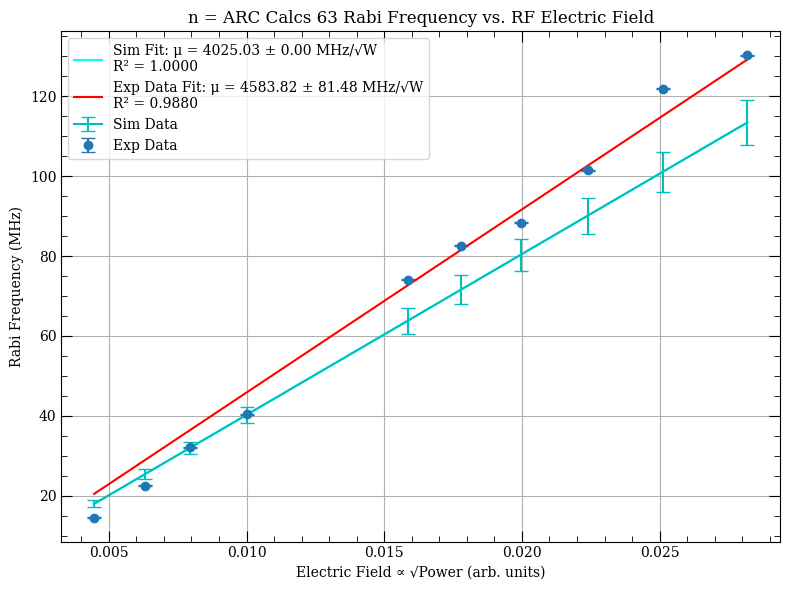

In [7]:
plt.figure(figsize=(8, 6))

# ARC Simulated Data
plt.errorbar(rf_fieldS, rabi_freqs_mhzS, yerr=rabi_errors_mhzS, fmt='c', label='Sim Data', capsize=5)
plt.plot(rf_field_fitS, rabi_fit_lineS, label=f'Sim Fit: μ = {mu_fitS:.2f} ± {mu_errS:.2f} MHz/√W\nR² = {r_squaredS:.4f}', color='cyan')

# Experimental Data
plt.errorbar(rf_field, rabi_freqs_mhz, yerr=rabi_errors_mhz, fmt='o', label='Exp Data', capsize=5)
plt.plot(rf_field_fit, rabi_fit_line, label=f'Exp Data Fit: μ = {mu_fit:.2f} ± {mu_err:.2f} MHz/√W\nR² = {r_squared:.4f}', color='red')

# figure labeling
plt.xlabel('Electric Field ∝ √Power (arb. units)')
plt.ylabel('Rabi Frequency (MHz)')
plt.title('n = ARC Calcs 63 Rabi Frequency vs. RF Electric Field')
plt.legend()
plt.grid(True)
plt.tight_layout()

### The next few code cells implement the expression of the electric field in V/m and thus the TDME in units of $[e a_0]$.

In [8]:
# Constants from Scipy
h_bar = const.hbar # reduced Planck's constant [J⋅s] 
Q = const.e # fundamental unit of charge [C]
a0 = const.physical_constants["Bohr radius"][0]  # Value in meters

In [9]:
# quartic fit
eta = -1.62253e-5 * n1**4 + 4.40859e-3 * n1**3 -0.445226 * n1**2 + 19.83168 * n1 - 328.01064
print("The predicted E-field scaling factor is:", eta)

The predicted E-field scaling factor is: 1.041391616700082


Scaled electric field strengths [V/m]: [0.63374192 0.89518425 1.1269702  1.41877142 2.24860117 2.52297201
 2.83082115 3.17623357 3.56379269 3.99864116]
Extracted dipole matrix element (μ): 2524.99 [e a0]
Extracted dipole matrix element (μ): 32.31 ± 0.57 MHz per √mW
R² value of the fit: 0.9880


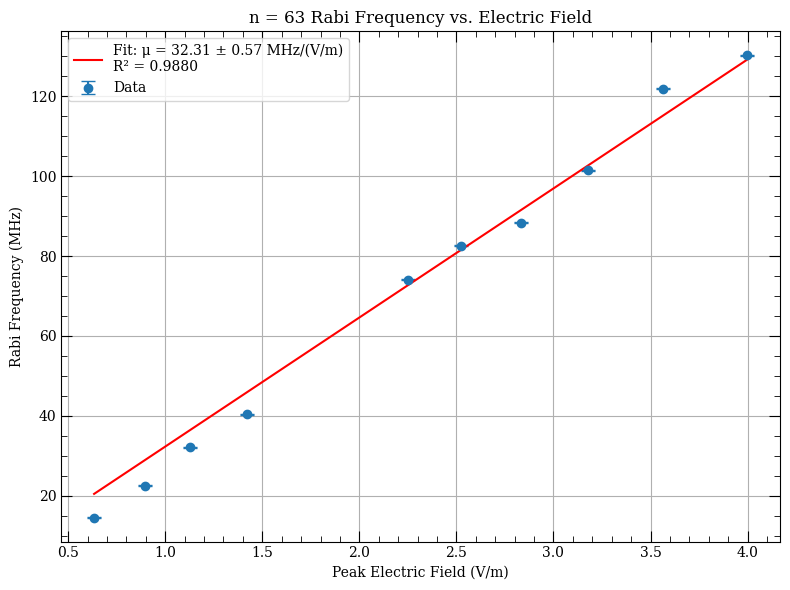

In [10]:
################### RF DELIVERY EFFICIENCY ################################
use_efficiency = False  # Set to False to disable efficiency factor
Eff = eta if use_efficiency else 1.14
############################################################################

E_peak = (1/r) * Eff* np.sqrt(60 * P * G) #[V/m] This is equation A9 from https://iopscience.iop.org/article/10.1088/1361-6455/ae407f

print("Scaled electric field strengths [V/m]:", E_peak)

# Electric field values
rf_field = E_peak # peak values

# Fit Rabi frequency vs. electric field to a linear model: Omega = mu * E / hbar
def linear_model(x, mu):
    return mu * x

popt, pcov = curve_fit(linear_model, rf_field, rabi_freqs_mhz, sigma=rabi_errors_mhz)
mu_fit = popt[0]
mu_err = np.sqrt(np.diag(pcov))[0]

# Generate fit line
rf_field_fit = np.linspace(min(rf_field), max(rf_field), 100)
rabi_fit_line = linear_model(rf_field_fit, mu_fit)

# Calculate R² value
residuals = rabi_freqs_mhz - linear_model(rf_field, mu_fit)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((rabi_freqs_mhz - np.mean(rabi_freqs_mhz))**2)
r_squared = 1 - (ss_res / ss_tot)

TDME = h_bar * 2 * np.pi * mu_fit * 1e6/(Q * a0) # This is how to calculate the TDME in units of [e a0]
print(f"Extracted dipole matrix element (μ): {TDME:.2f} [e a0]")

# Plotting with matplotlib
plt.figure(figsize=(8, 6))
plt.errorbar(rf_field, rabi_freqs_mhz, yerr=rabi_errors_mhz, fmt='o', label='Data', capsize=5)
plt.plot(rf_field_fit, rabi_fit_line, label=f'Fit: μ = {mu_fit:.2f} ± {mu_err:.2f} MHz/(V/m)\nR² = {r_squared:.4f}', color='red')
plt.xlabel('Peak Electric Field (V/m)')
plt.ylabel('Rabi Frequency (MHz)')
plt.title('n = 63 Rabi Frequency vs. Electric Field')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Report dipole matrix element and R²
print(f"Extracted dipole matrix element (μ): {mu_fit:.2f} ± {mu_err:.2f} MHz per √mW")
print(f"R² value of the fit: {r_squared:.4f}")


In [11]:
# Define array of peak electric field values [V/m] (see Easy dBm code)
E_array = E_peak  # Peak values

# Compute Rabi frequencies for each E
rabi_array = np.array([
    atom.getRabiFrequency2(n1, l1, j1, mj1, n3, l3, j3, q, E)/(2*np.pi*1e6)
    for E in E_array
])

# Print results
for E, rabi in zip(E_array, rabi_array):
    print(f"E = {E:.3f} V/m → Rabi Frequency = {rabi:.3f} MHz")

E = 0.634 V/m → Rabi Frequency = 20.496 MHz
E = 0.895 V/m → Rabi Frequency = 28.952 MHz
E = 1.127 V/m → Rabi Frequency = 36.448 MHz
E = 1.419 V/m → Rabi Frequency = 45.885 MHz
E = 2.249 V/m → Rabi Frequency = 72.723 MHz
E = 2.523 V/m → Rabi Frequency = 81.597 MHz
E = 2.831 V/m → Rabi Frequency = 91.553 MHz
E = 3.176 V/m → Rabi Frequency = 102.725 MHz
E = 3.564 V/m → Rabi Frequency = 115.259 MHz
E = 3.999 V/m → Rabi Frequency = 129.323 MHz


Extracted dipole matrix element from ARC(μ): 2527.59 [e a0]


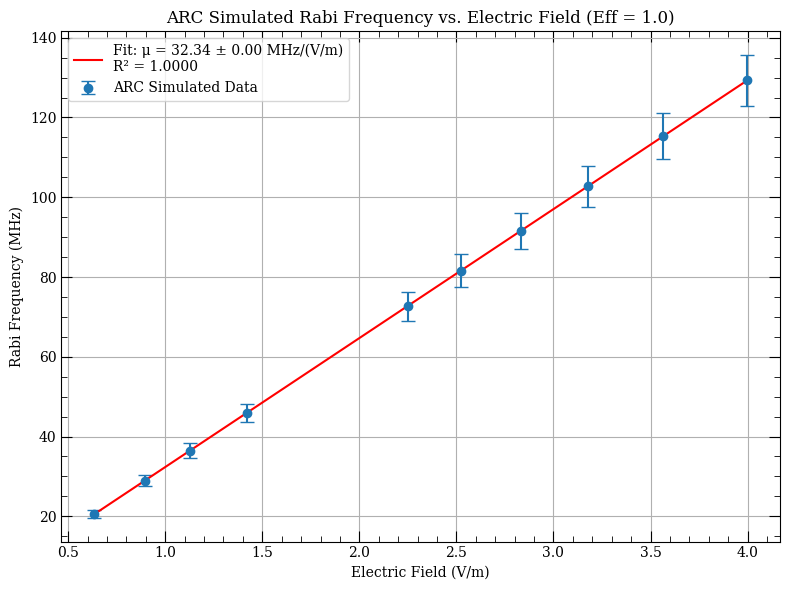

In [12]:
# ARC-generated Rabi frequencies in MHz
rabi_freqs_mhzS = rabi_array

# Define linear model
def linear_model(x, mu):
    return mu * x

# Estimate uncertainties (5% of Rabi frequency)
rabi_errorsS = rabi_freqs_mhzS * 0.05

# Fit the model
popt, pcov = curve_fit(linear_model, E_peak, rabi_freqs_mhzS, sigma=rabi_errorsS)
mu_fitS = popt[0]
mu_errS = np.sqrt(np.diag(pcov))[0]

# Calculate R²
residualsS = rabi_freqs_mhzS - linear_model(E_peak, mu_fitS)
ss_resS = np.sum(residualsS**2)
ss_totS = np.sum((rabi_freqs_mhzS - np.mean(rabi_freqs_mhzS))**2)
r_squaredS = 1 - (ss_resS / ss_totS)

# Generate fit line
E_fit = np.linspace(min(E_peak), max(E_peak), 100)
rabi_fit_lineS = linear_model(E_fit, mu_fitS)

TDMES = h_bar * 2 * np.pi * mu_fitS * 1e6/(Q * a0)
print(f"Extracted dipole matrix element from ARC(μ): {TDMES:.2f} [e a0]")

# Plotting
plt.figure(figsize=(8, 6))
plt.errorbar(E_peak, rabi_freqs_mhzS, yerr=rabi_errorsS, fmt='o', label='ARC Simulated Data', capsize=5)
plt.plot(E_fit, rabi_fit_lineS, label=f'Fit: μ = {mu_fitS:.2f} ± {mu_errS:.2f} MHz/(V/m)\nR² = {r_squaredS:.4f}', color='red')
plt.xlabel('Electric Field (V/m)')
plt.ylabel('Rabi Frequency (MHz)')
plt.title('ARC Simulated Rabi Frequency vs. Electric Field (Eff = 1.0)')
plt.legend()
plt.grid(True)
plt.tight_layout()

### Again, now a combined plot of the TDME where the electric field is expressed in $[V/m]$.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


<Figure size 640x480 with 0 Axes>

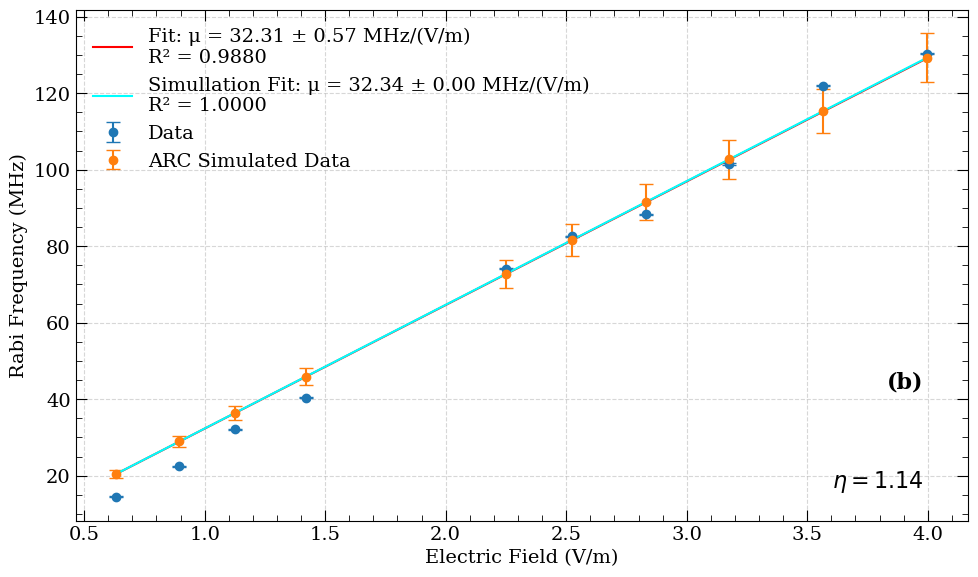

In [17]:
plt.rcParams.update({'font.family': 'serif', 'font.size': 14})
plt.subplots_adjust(left=0.15)
plt.figure(figsize=(10, 6))
plt.errorbar(rf_field, rabi_freqs_mhz, yerr=rabi_errors_mhz, fmt='o', label='Data', capsize=5)
plt.plot(rf_field_fit, rabi_fit_line, label=f'Fit: μ = {mu_fit:.2f} ± {mu_err:.2f} MHz/(V/m)\nR² = {r_squared:.4f}', color='red', lw=1.5)
plt.errorbar(E_peak, rabi_freqs_mhzS, yerr=rabi_errorsS, fmt='o', label='ARC Simulated Data', capsize=5)
plt.plot(E_fit, rabi_fit_lineS, label=f'Simullation Fit: μ = {mu_fitS:.2f} ± {mu_errS:.2f} MHz/(V/m)\nR² = {r_squaredS:.4f}', color='cyan', lw=1.5)
plt.xlabel('Electric Field (V/m)')
plt.ylabel('Rabi Frequency (MHz)')
# plt.title(f'(n = 63) Rabi Frequency vs. RF Electric Field (Eff={Eff})')
plt.text(
    0.95, 0.05,
    r'$\eta = 1.14$',
    transform=plt.gca().transAxes,
    fontsize=16,
    fontweight='bold',
    ha='right',
    va='bottom'
)
plt.text(0.95, 0.25, '(b)', transform=plt.gca().transAxes,
         fontsize=16, fontweight='bold', ha='right', va='bottom')
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('n63_validation_Eff_on1.eps')

In [14]:
# Percent difference in TDME
print(f"The percent difference between the ARC calculated and measured dipole matrix elements (μ): {100* np.abs(TDME - TDMES)/TDMES:.2f} ")

The percent difference between the ARC calculated and measured dipole matrix elements (μ): 0.10 
